In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from database_connection import load_data

In [9]:
df.isnull().sum()

id               0
response_time    0
gender           0
return_plan      0
reason           0
dtype: int64

In [35]:
df['return_plan'].value_counts()

return_plan
Not Sure    38
No          26
Yes         18
Name: count, dtype: int64

In [42]:
return_counts = df['return_plan'].value_counts()
return_percent = df['return_plan'].value_counts(normalize=True) * 100

print(return_counts)
print("\nPercentages:\n", return_percent.round(2))

return_plan
Not Sure    38
No          26
Yes         18
Name: count, dtype: int64

Percentages:
 return_plan
Not Sure    46.34
No          31.71
Yes         21.95
Name: proportion, dtype: float64


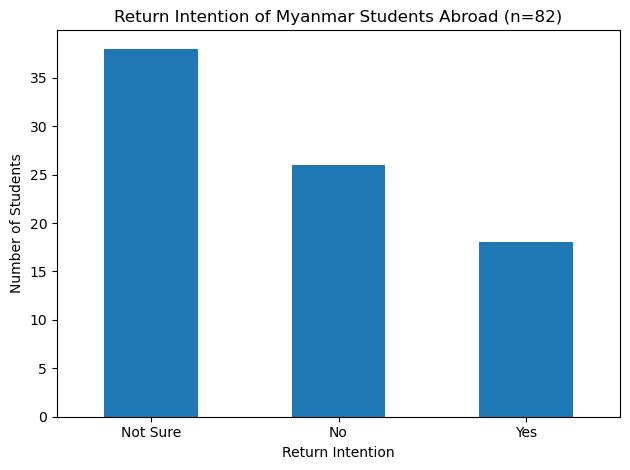

In [43]:
import matplotlib.pyplot as plt

plt.figure()
df['return_plan'].value_counts().plot(kind='bar')

plt.title("Return Intention of Myanmar Students Abroad (n=82)")
plt.xlabel("Return Intention")
plt.ylabel("Number of Students")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [44]:
total = len(df)
no_count = (df['return_plan'] == "No").sum()
not_sure_count = (df['return_plan'] == "Not Sure").sum()

brain_drain_risk = (no_count + not_sure_count) / total * 100
round(brain_drain_risk, 2)

np.float64(78.05)

In [45]:
from statsmodels.stats.proportion import proportions_ztest

count_yes = (df['return_plan'] == "Yes").sum()
n = len(df)

stat, p_value = proportions_ztest(count_yes, n, value=0.5)

round(stat, 4), round(p_value, 6)

(np.float64(-6.1363), np.float64(0.0))

In [46]:
from statsmodels.stats.proportion import proportions_ztest
count_yes = (df['return_plan'] == "Yes").sum()
n = len(df)
stat, p_value = proportions_ztest(count_yes, n, value=0.5)
print("Observed Return Rate:", round(count_yes/n, 4))
print("Z-statistic:", round(stat, 4))
print("P-value:", round(p_value, 6))

Observed Return Rate: 0.2195
Z-statistic: -6.1363
P-value: 0.0


In [47]:
from statsmodels.stats.proportion import proportion_confint
ci_low, ci_high = proportion_confint(count_yes, n, alpha=0.05, method='normal')
print("95% Confidence Interval:")
print(round(ci_low*100, 2), "% to", round(ci_high*100, 2), "%")

95% Confidence Interval:
12.99 % to 30.91 %


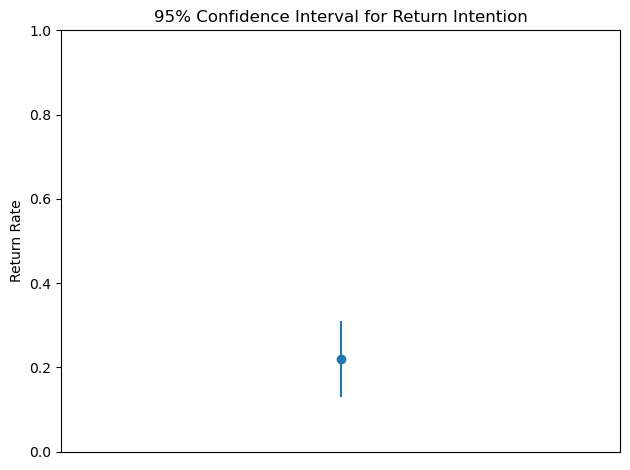

In [48]:
import matplotlib.pyplot as plt

return_rate = count_yes / n

plt.figure()
plt.errorbar(
    x=1,
    y=return_rate,
    yerr=[[return_rate-ci_low], [ci_high-return_rate]],
    fmt='o'
)

plt.xticks([])
plt.ylabel("Return Rate")
plt.title("95% Confidence Interval for Return Intention")

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [49]:
import pandas as pd
import scipy.stats as stats
contingency_table = pd.crosstab(df['gender'], df['return_plan'])

contingency_table

return_plan,No,Not Sure,Yes
gender,,,
Female,12,22,8
Male,14,16,10


In [50]:
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print("Chi-square:", round(chi2, 4))
print("Degrees of freedom:", dof)
print("P-value:", round(p, 6))

Chi-square: 1.2754
Degrees of freedom: 2
P-value: 0.528503


In [52]:
pd.crosstab(df['reason'], df['return_plan'])

return_plan,No,Not Sure,Yes
reason,,,
\r,0,0,15
Better job opportunities abroad\r,6,12,0
Better quality of life abroad\r,6,3,0
Family reasons\r,2,1,2
Further study plans\r,2,8,1
Higher salary abroad\r,1,4,0
Political situation\r,9,9,0
The main thing is Political situation and everything depends on it \r,0,1,0


In [53]:
import scipy.stats as stats

contingency_reason = pd.crosstab(df['reason'], df['return_plan'])

chi2_r, p_r, dof_r, expected_r = stats.chi2_contingency(contingency_reason)

print("Chi-square:", round(chi2_r, 4))
print("Degrees of freedom:", dof_r)
print("P-value:", round(p_r, 6))

Chi-square: 78.9893
Degrees of freedom: 14
P-value: 0.0


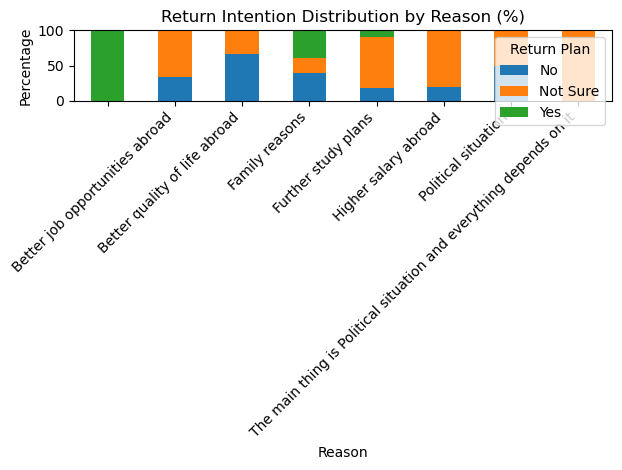

In [57]:
# Percentage table
contingency_percent = pd.crosstab(
    df['reason'],
    df['return_plan'],
    normalize='index'
) * 100

contingency_percent.plot(kind='bar', stacked=True)

plt.title("Return Intention Distribution by Reason (%)")
plt.xlabel("Reason")
plt.ylabel("Percentage")

plt.xticks(rotation=45, ha='right')
plt.legend(title="Return Plan")
plt.tight_layout()
plt.show()

In [58]:
import numpy as np

# Recreate contingency table (cleaned)
df['reason'] = df['reason'].str.strip()
contingency_reason = pd.crosstab(df['reason'], df['return_plan'])

chi2, p, dof, expected = stats.chi2_contingency(contingency_reason)

n = contingency_reason.values.sum()
min_dim = min(contingency_reason.shape) - 1

cramers_v = np.sqrt(chi2 / (n * min_dim))

print("Cramér's V:", round(cramers_v, 4))

Cramér's V: 0.694


In [8]:
df = load_data()

df.head()

,id,response_time,gender,return_plan,reason
0,1,2026-02-07 15:30:13,Male,Not Sure,Better quality of life abroad\r
1,2,2026-02-07 15:33:18,Male,Not Sure,Political situation\r
2,3,2026-02-07 15:34:42,Female,Not Sure,Better job opportunities abroad\r
3,4,2026-02-07 15:45:12,Female,No,Political situation\r
4,5,2026-02-07 15:45:38,Female,No,Family reasons\r


In [33]:
df.columns

Index(['id', 'response_time', 'gender', 'return_plan', 'reason'], dtype='str')

In [32]:
df.shape

(82, 5)

In [14]:
return_counts = df['return_plan'].value_counts()
return_percent = df['return_plan'].value_counts(normalize=True) * 100

print("Counts:\n", return_counts)
print("\nPercentages:\n", return_percent.round(2))

Counts:
 return_plan
Not Sure    38
No          26
Yes         18
Name: count, dtype: int64

Percentages:
 return_plan
Not Sure    46.34
No          31.71
Yes         21.95
Name: proportion, dtype: float64


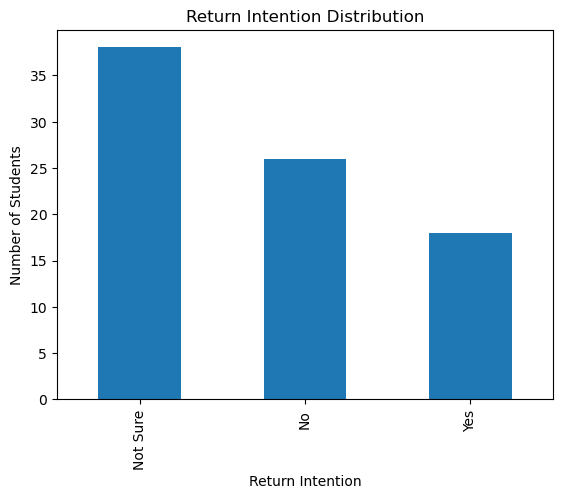

In [15]:
import matplotlib.pyplot as plt

plt.figure()
df['return_plan'].value_counts().plot(kind='bar')

plt.title("Return Intention Distribution")
plt.xlabel("Return Intention")
plt.ylabel("Number of Students")

plt.show()

In [51]:
total = len(df)

no_count = (df['return_plan'] == "No").sum()
not_sure_count = (df['return_plan'] == "Not Sure").sum()

brain_drain_risk = (no_count + not_sure_count) / total * 100

print("Brain Drain Risk (%):", round(brain_drain_risk, 1))

Brain Drain Risk (%): 78.0


In [17]:
from statsmodels.stats.proportion import proportions_ztest

count_yes = (df['return_plan'] == "Yes").sum()
n = len(df)

stat, p_value = proportions_ztest(count_yes, n, value=0.5)

print("Z-statistic:", round(stat, 4))
print("P-value:", round(p_value, 6))

Z-statistic: -6.1363
P-value: 0.0


In [18]:
from statsmodels.stats.proportion import proportion_confint

ci_low, ci_high = proportion_confint(count_yes, n, alpha=0.05, method='normal')

print("95% Confidence Interval:")
print(round(ci_low*100,2), "% to", round(ci_high*100,2), "%")

95% Confidence Interval:
12.99 % to 30.91 %


In [19]:
import scipy.stats as stats

contingency_table = pd.crosstab(df['gender'], df['return_plan'])
contingency_table

return_plan,No,Not Sure,Yes
gender,,,
Female,12,22,8
Male,14,16,10


In [20]:
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square:", round(chi2,4))
print("P-value:", round(p,6))

Chi-square: 1.2754
P-value: 0.528503


In [21]:
import numpy as np

n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))

print("Cramér's V:", round(cramers_v,4))

Cramér's V: 0.1247


In [22]:
reason_percent = df['reason'].value_counts(normalize=True) * 100
reason_percent.round(2)

reason
Political situation\r                                                    21.95
Better job opportunities abroad\r                                        21.95
\r                                                                       18.29
Further study plans\r                                                    13.41
Better quality of life abroad\r                                          10.98
Family reasons\r                                                          6.10
Higher salary abroad\r                                                    6.10
The main thing is Political situation and everything depends on it \r     1.22
Name: proportion, dtype: float64

) missing from font(s) DejaVu Sans.aul_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


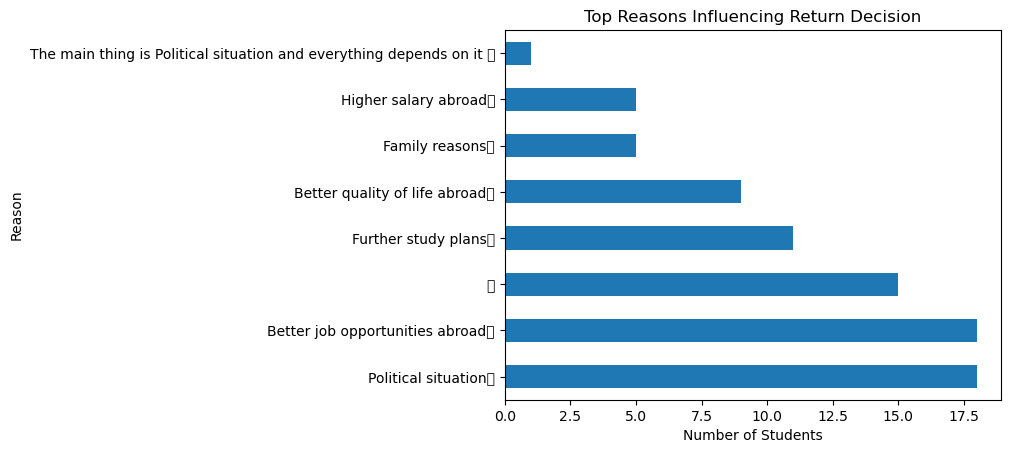

In [23]:
plt.figure()
df['reason'].value_counts().plot(kind='barh')

plt.title("Top Reasons Influencing Return Decision")
plt.xlabel("Number of Students")
plt.ylabel("Reason")

plt.show()

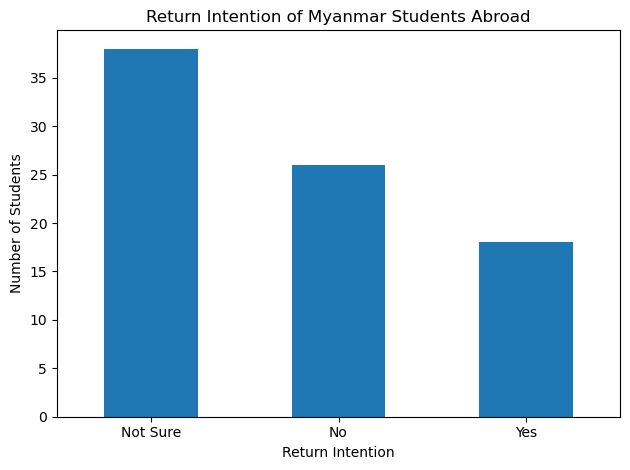

In [24]:
import matplotlib.pyplot as plt

counts = df['return_plan'].value_counts()

plt.figure()
counts.plot(kind='bar')

plt.title("Return Intention of Myanmar Students Abroad")
plt.xlabel("Return Intention")
plt.ylabel("Number of Students")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

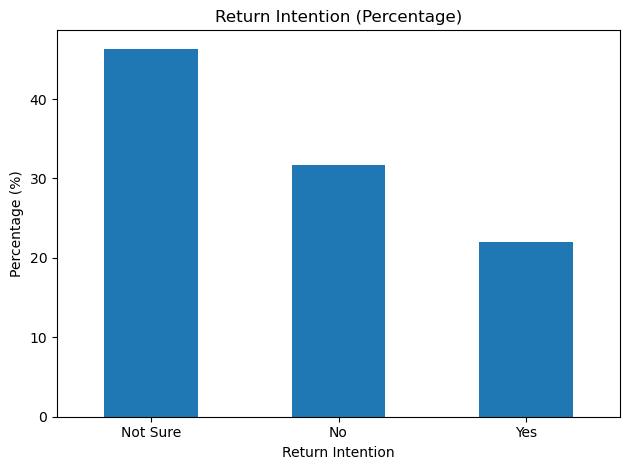

In [25]:
percent = df['return_plan'].value_counts(normalize=True) * 100

plt.figure()
percent.plot(kind='bar')

plt.title("Return Intention (Percentage)")
plt.xlabel("Return Intention")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

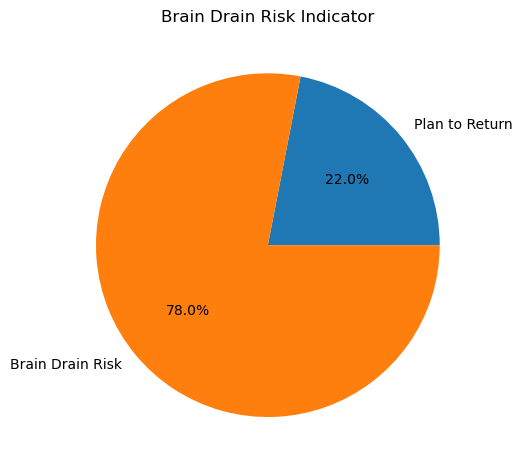

In [26]:
total = len(df)
no_count = (df['return_plan'] == "No").sum()
not_sure_count = (df['return_plan'] == "Not Sure").sum()
yes_count = (df['return_plan'] == "Yes").sum()

risk = no_count + not_sure_count

plt.figure()

plt.pie([yes_count, risk],
        labels=["Plan to Return", "Brain Drain Risk"],
        autopct='%1.1f%%')

plt.title("Brain Drain Risk Indicator")
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

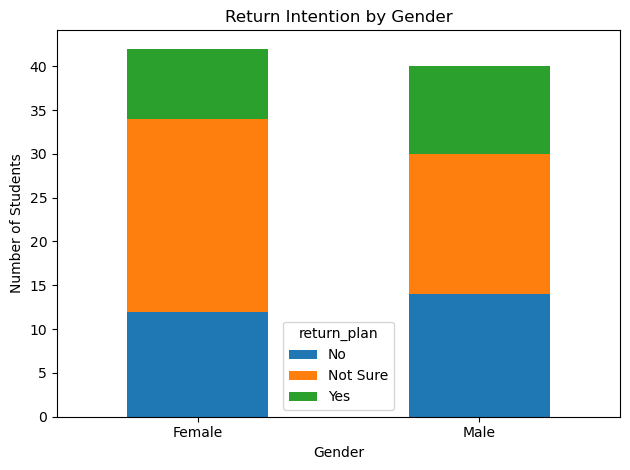

In [27]:
ct = pd.crosstab(df['gender'], df['return_plan'])

plt.figure()
ct.plot(kind='bar', stacked=True)

plt.title("Return Intention by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

) missing from font(s) DejaVu Sans.\Temp\ipykernel_10976\1828118731.py:10: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.aul_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


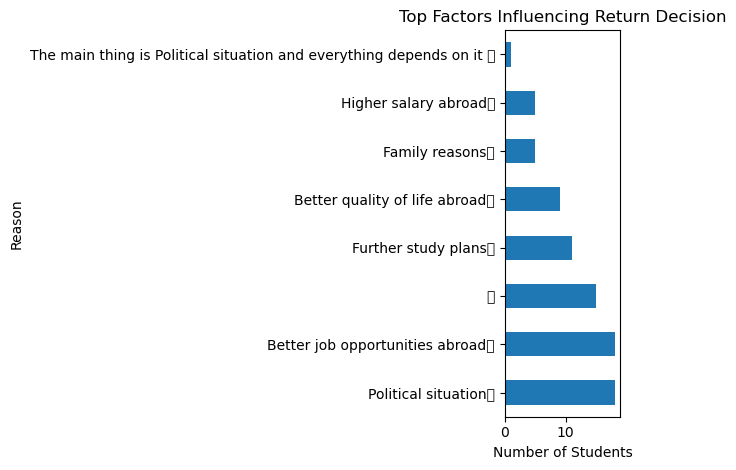

In [28]:
reason_counts = df['reason'].value_counts()

plt.figure()
reason_counts.plot(kind='barh')

plt.title("Top Factors Influencing Return Decision")
plt.xlabel("Number of Students")
plt.ylabel("Reason")

plt.tight_layout()
plt.show()

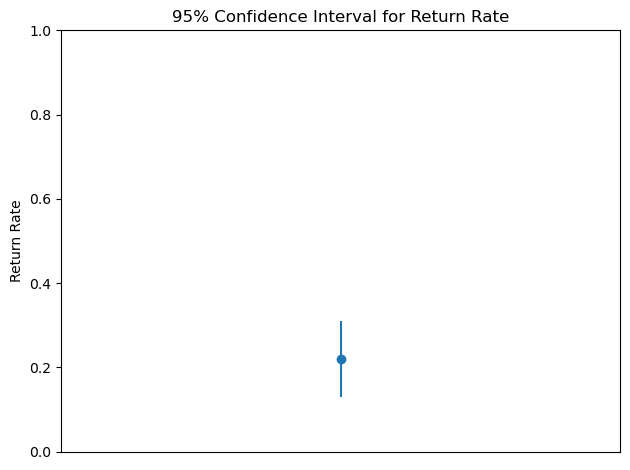

In [29]:
from statsmodels.stats.proportion import proportion_confint

count_yes = (df['return_plan'] == "Yes").sum()
n = len(df)

ci_low, ci_high = proportion_confint(count_yes, n, alpha=0.05)

return_rate = count_yes / n

plt.figure()
plt.errorbar(x=1, y=return_rate, 
             yerr=[[return_rate-ci_low], [ci_high-return_rate]],
             fmt='o')

plt.xticks([])
plt.ylabel("Return Rate")
plt.title("95% Confidence Interval for Return Rate")

plt.ylim(0,1)
plt.tight_layout()
plt.show()